# System Long-Term Performance Analysis

This notebook analyzes long-term performance metrics and their correlations with following operation metrics:
1. Pack SoC variability
2. Pack C-rate
3. Cell Volts imbalance
4. Time spent by packs as idle
5. Active nodes

### Analysis Structure:
1. Data Loading
2. Metric Computations (SoC, C-Rate, Idle Time, Voltage Imbalance, Efficiency, Power Stability, SoH, Aux Energy Usage)
3. Individual Correlation Analyses

Data: 30-minute aggregated data per pack

## 1. Data Loading & Cleaning

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cepy import EstorDatasetSummary
import seaborn as sns
from cepy.aws_query import AwsQuery
pd.options.mode.chained_assignment = None  # Suppress SettingWithCopyWarning

In [2]:
#set global plot style
plt.rcParams['figure.figsize'] = (14,4)
plt.rcParams['image.cmap'] = 'Paired'

In [3]:
# Load CSV file directly from current folder
system_id = '0015'

try:
    df = pd.read_csv(f'sys{system_id}_performance_exploration.csv', parse_dates=[0])
    df = df.set_index('date_and_time')
    df = df.sort_index()
    df['hour_of_day'] = df.index.hour + df.index.minute / 60
    battery_mapping = pd.read_csv('E-STOR300-360.csv')
    # df_monthly = pd.read_csv(f'sys{system_id}_monthly_data.csv', parse_dates=[0])
    # df_monthly = df.set_index('date_and_time')
    # df_monthly = df.sort_index()
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Duration: {(df.index.max() - df.index.min()).days} days")
    display(df.head(5))
except FileNotFoundError:
    print(f"File not found for system: {system_id}")
    print(f"Available files: {os.listdir('.')[:10]}")

Date range: 2024-01-01 00:00:00+00:00 to 2024-12-31 23:30:00+00:00
Duration: 365 days


,power_request_channel1,power_request_channel2,power_request_channel3,power_request_channel4,power_request_channel5,power_request_channel6,current_b1a,current_b1b,current_b2a,current_b2b,...,power_request_b8b,power_request_b9a,power_request_b9b,power_request_b10a,power_request_b10b,power_request_b11a,power_request_b11b,power_request_b12a,power_request_b12b,hour_of_day
date_and_time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.2,-0.5,-0.2,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2024-01-01 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,-1.0,0.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.5
2024-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,-1.2,-0.2,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2024-01-01 01:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,-0.5,-0.2,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.5
2024-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,-0.8,0.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [4]:
#fill power_request na values with 0
power_request_cols = df.filter(regex=r'^power_request').columns
df[power_request_cols] = df[power_request_cols].fillna(0)

In [5]:
# plt.plot(df.filter(regex=r'^power_flow_esd'))

In [6]:
#Read daily data - to convert to weekly and monthly
eds_daily = EstorDatasetSummary(
    system_id='0011',
    date_start='2024-01-01',
    date_end='2024-12-31',
    freq="D",
    patterns = [
                    "state_of_charge_esd",
                    "energy_services",
                    "^charge_esd",
                    "^discharge_esd",
                    "^power_flow_esd",
                    "n_samples$"
                ],
    read_query="query"
)

df_weekly = eds_daily.aggregate(df = eds_daily.df, freq = 'W-SUN')
df_monthly = eds_daily.aggregate(df = eds_daily.df, freq = 'MS')


In [8]:
#Separate out the columns
soc_cols = df.filter(regex=r'^state_of_charge').columns
charge_cols = df.filter(regex=r'^charge_b\d+').columns
discharge_cols = df.filter(regex=r'^discharge_b\d+').columns
cell_voltage_cols = df.filter(regex=r'cell_volts_b\d+').columns
bus_voltage_cols = df.filter(regex=r'bus_volts_b\d+').columns
power_cols = df.filter(regex=r'^power_flow_b\d+').columns
energy_cols = df.filter(regex=r'energy_service').columns
esd_cols = df.filter(regex=r"esd").columns
current_cols = df.filter(regex=r'^current_b\d+').columns

battery_packs = charge_cols.str.replace('charge_', '').to_list()

df_columns = {
    'battery_packs': battery_packs,
    'soc': soc_cols,
    'charge': charge_cols,
    'discharge': discharge_cols,
    'cell_voltage': cell_voltage_cols,
    'bus_voltage': bus_voltage_cols,
    'power': power_cols,
    'power_request': power_request_cols,
    'energy': energy_cols,
    'system_level': esd_cols
}


print("Column Type Summary:")
for ctype, col in df_columns.items():
    print(f"{ctype}: {len(col)} columns")
    print(f"Examples: {list(col[:5])}")


Column Type Summary:
battery_packs: 24 columns
Examples: ['b1a', 'b1b', 'b2a', 'b2b', 'b3a']
soc: 25 columns
Examples: ['state_of_charge_b1a', 'state_of_charge_b1b', 'state_of_charge_b2a', 'state_of_charge_b2b', 'state_of_charge_b3a']
charge: 24 columns
Examples: ['charge_b1a', 'charge_b1b', 'charge_b2a', 'charge_b2b', 'charge_b3a']
discharge: 24 columns
Examples: ['discharge_b1a', 'discharge_b1b', 'discharge_b2a', 'discharge_b2b', 'discharge_b3a']
cell_voltage: 24 columns
Examples: ['delta_cell_volts_b1a', 'delta_cell_volts_b1b', 'delta_cell_volts_b2a', 'delta_cell_volts_b2b', 'delta_cell_volts_b3a']
bus_voltage: 24 columns
Examples: ['bus_volts_b1a', 'bus_volts_b1b', 'bus_volts_b2a', 'bus_volts_b2b', 'bus_volts_b3a']
power: 24 columns
Examples: ['power_flow_b1a', 'power_flow_b1b', 'power_flow_b2a', 'power_flow_b2b', 'power_flow_b3a']
power_request: 30 columns
Examples: ['power_request_channel1', 'power_request_channel2', 'power_request_channel3', 'power_request_channel4', 'power_requ

In [9]:
## Function - Computation and Plots
def plot_correlation(df, x, y, corr_df):
    correlation = df[x].corr(df[y])

    # ax.scatter(x, y, alpha=0.6, s=50, color='steelblue')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(corr_df[x], corr_df[y], alpha=0.6, s=50, color='steelblue')

    # Trend line
    z = np.polyfit(corr_df[x], corr_df[y], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(corr_df[x].min(), corr_df[x].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line')

    ax.set_xlabel(f'{x.capitalize()}')
    ax.set_ylabel(f'{y.capitalize()}')
    ax.set_title(f'{x.capitalize()} vs {y.capitalize()}\n(Correlation: r={correlation:.3f})')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

    fig.tight_layout()


def compute_diff_btw_packs(df_filtered, battery_mapping, variable:str):
    for node in battery_mapping['node'].unique():
        pack_cols = battery_mapping.loc[battery_mapping['node'] == node, 'position'].values
        df_filtered[f'delta_{variable}_{node}'] = df_filtered.filter(regex='|'.join('b'+pack_cols)).diff(axis=1).max(axis=1)
    return round(df_filtered, 3)

def compute_correlations(df, x_var, y_vars):
    results = []
    
    for y_var in y_vars:
        pearson_corr = df[x_var].corr(df[y_var], method='pearson'),
        spearman_corr = df[x_var].corr(df[y_var], method='spearman')
        
        results.append({
            'x_variable': x_var,
            'y_variable': y_var,
            'pearson_r': pearson_corr,
            # 'pearson_p': pearson_p,
            'spearman_r': spearman_corr,
            # 'spearman_p': spearman_p,
            # 'significant': pearson_p < 0.05
        })
    
    return pd.DataFrame(results)

## 2. Peformance Metric Computation


### Efficiency

In [10]:
# drop df values where charge is 0 
df_filtered = df_weekly[df_weekly['charge_esd'] != 0]
df_weekly['efficiency'] = (round(df_filtered['discharge_esd']/df_filtered['charge_esd'].abs(),3)*100)
print(f"\nEfficiency:")
print(df_weekly['efficiency'].describe())


Efficiency:
count     46.000000
mean      87.243478
std        5.228157
min       64.000000
25%       87.125000
50%       87.600000
75%       88.275000
max      107.900000
Name: efficiency, dtype: float64


In [11]:
#efficiency pack
df_weekly_pack = df.filter(regex=r'^(charge|discharge)_b\d+').resample('W-SUN').sum()
for pack in battery_packs:
    df_weekly[f'efficiency_{pack}'] = (df_weekly_pack[f'discharge_{pack}']/df_weekly_pack[f'charge_{pack}'].abs())*100


### Aux Energy

In [12]:
# 2.2 Compute Efficiency & Auxiliary Energy Metrics
print(df['energy_services'].describe())

df_weekly['aux_energy'] = df['energy_services'].resample('W-SUN').sum()

count    13766.000000
mean         0.727018
std          1.117097
min          0.072083
25%          0.210000
50%          0.270000
75%          0.628750
max         12.723750
Name: energy_services, dtype: float64


### SoH (pack level)

At pack level, SoH is defined as the percentage capacity from first life of the pack

In [13]:
#download files from s3
query_str = f"""
SELECT unit, unit_type, system_id, date_grouped, date_test, percent_capacity_first_life
FROM "capacity_test_results_systems"
where system_id='{system_id}' and unit_type='battery' and Date(date_test) > Date('2021-12-31')
"""

db_name = "estor"
output_location = "s3://aws-athena-query-results-eu-west-1-678133867981"
aq = AwsQuery(db_name, output_location)
# get soh at esd level and node level
soh_pack_df = aq.query(query_str)

soh_pack_df["date_grouped"] = pd.to_datetime(soh_pack_df["date_grouped"]).dt.date
soh_pack_df["date_test"] = pd.to_datetime(soh_pack_df["date_test"]).dt.date

soh_pack_df = soh_pack_df.sort_values(by=['date_grouped', 'unit'])
soh_pack_df.reset_index(drop=True, inplace=True)

display(soh_pack_df.head(10))

,unit,unit_type,system_id,date_grouped,date_test,percent_capacity_first_life
0,b10a,battery,0015,2022-01-15,2022-01-15,65.03
1,b10b,battery,0015,2022-01-15,2022-01-15,65.03
2,b11a,battery,0015,2022-01-15,2022-01-15,67.11
3,b11b,battery,0015,2022-01-15,2022-01-15,67.11
4,b12a,battery,0015,2022-01-15,2022-01-15,65.64
5,b12b,battery,0015,2022-01-15,2022-01-15,65.64
6,b1a,battery,0015,2022-01-15,2022-01-16,60.37
7,b1b,battery,0015,2022-01-15,2022-01-16,60.37
8,b2a,battery,0015,2022-01-15,2022-01-16,59.86
9,b2b,battery,0015,2022-01-15,2022-01-16,59.86


### Internal Resistance

To compute internal resistance we look at the changes in current when voltage drops. Lower internal resistance is crucial for higher power output and efficiency, as higher resistance generates excessive heat, reduces voltage, and accelerates battery degradation.

In [14]:
#internal resistance
current_threshold = 0.01  # adjust based on system scale
resistance_df = df.filter(regex=r'^current|^bus_volts').copy()

for pack in battery_packs:
    valid_current = resistance_df[resistance_df[f'current_{pack}'].abs() > current_threshold][f'current_{pack}'].abs()
    resistance_df[f"dI_{pack}"] = valid_current.diff()
    resistance_df[f"dV_{pack}"] = resistance_df[f"bus_volts_{pack}"].diff()

    threshold = 10  # A change threshold

    step_events = resistance_df[resistance_df[f"dV_{pack}"].abs() > threshold]

    #estimate of pack internal resistance calculated at moments where current changes sharply.
    df[f"resistance_estimate_{pack}"] = step_events[f"dV_{pack}"] / step_events[f"dI_{pack}"]

df.filter(like='resistance')

,resistance_estimate_b1a,resistance_estimate_b1b,resistance_estimate_b2a,resistance_estimate_b2b,resistance_estimate_b3a,resistance_estimate_b3b,resistance_estimate_b4a,resistance_estimate_b4b,resistance_estimate_b5a,resistance_estimate_b5b,...,resistance_estimate_b8a,resistance_estimate_b8b,resistance_estimate_b9a,resistance_estimate_b9b,resistance_estimate_b10a,resistance_estimate_b10b,resistance_estimate_b11a,resistance_estimate_b11b,resistance_estimate_b12a,resistance_estimate_b12b
date_and_time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 22:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### C-Rate

C-rate of a battery refers to the rate at which a battery is charged or discharged.
A C-rate of 1C indicates the cell is being charged or discharged at a rate equal to its capacity with a duration of 1hr.
A higher C-rate means faster charging/discharging duration, but also can lead to reduction in overall lifespan of the pack.

While currently we are only exploring the C-rate against system efficiency and SoH, we can also look at how SoC and temp impacts the C-rate at smaller cycles.
We can also correlate it to voltage drops when C-rate is high

In [15]:
#system level crate to relate with efficiency
#node level crate to relate with SoH

# seperate power_flow_esd into charge and discharge columns
power_flow_df = df[current_cols].copy()
charge_pack_df = power_flow_df[power_flow_df < 0]
discharge_pack_df = power_flow_df[power_flow_df > 0]


In [17]:
# 2.3 Compute C-Rate Metric 
system_capacity = 360
num_of_packs = 24
pack_capacity = system_capacity / num_of_packs  # 15 kWh per pack
discharge_data = df[discharge_cols].copy()
charge_data = df[charge_cols].copy()

#pack level charge c-rate
crate_charge_pack = charge_pack_df.abs()/ pack_capacity
# Mean current across all packs, normalized by rated capacity (15 kWh per pack)
total_charge = charge_pack_df.abs().mean(axis=1)
# C-rate = Power (kW) / Capacity (kWh)
crate_charge = total_charge / system_capacity 

#pack level discharge c-rate
crate_discharge_pack = discharge_pack_df.abs()/ pack_capacity
# Mean current across all packs, normalized by rated capacity (15 kWh per pack)
total_discharge = discharge_pack_df.abs().mean(axis=1)
# C-rate = Power (kW) / Capacity (kWh)
crate_discharge = total_discharge / system_capacity 

crate_pack = df[power_cols].abs() / pack_capacity


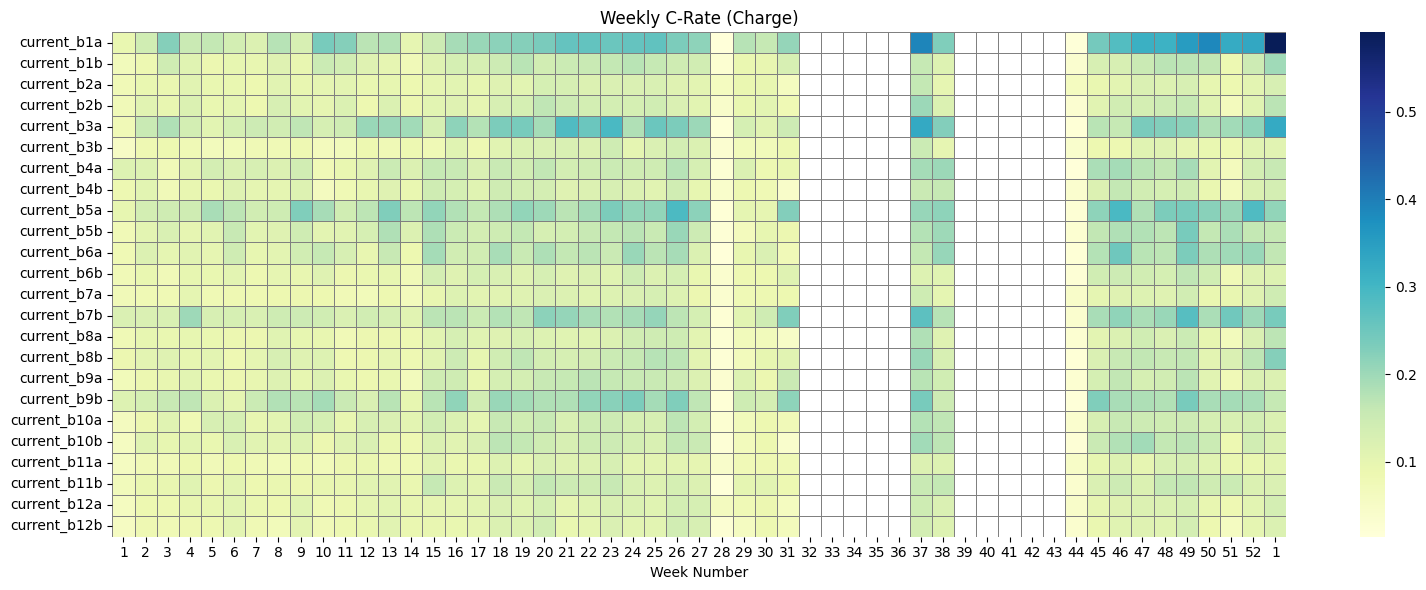

In [18]:
fig, ax = plt.subplots(figsize=(16, 6))

crate_charge_pack_weekly = crate_charge_pack.resample('W-SUN').mean()

# Create heatmap
sns.heatmap(
    crate_charge_pack_weekly.T,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    ax=ax,
    xticklabels=crate_charge_pack_weekly.index.isocalendar().week,
    yticklabels=crate_charge_pack_weekly.columns.str.replace('charge_', ''),
)

ax.set_xlabel('Week Number')
ax.set_title('Weekly C-Rate (Charge)')

plt.tight_layout()

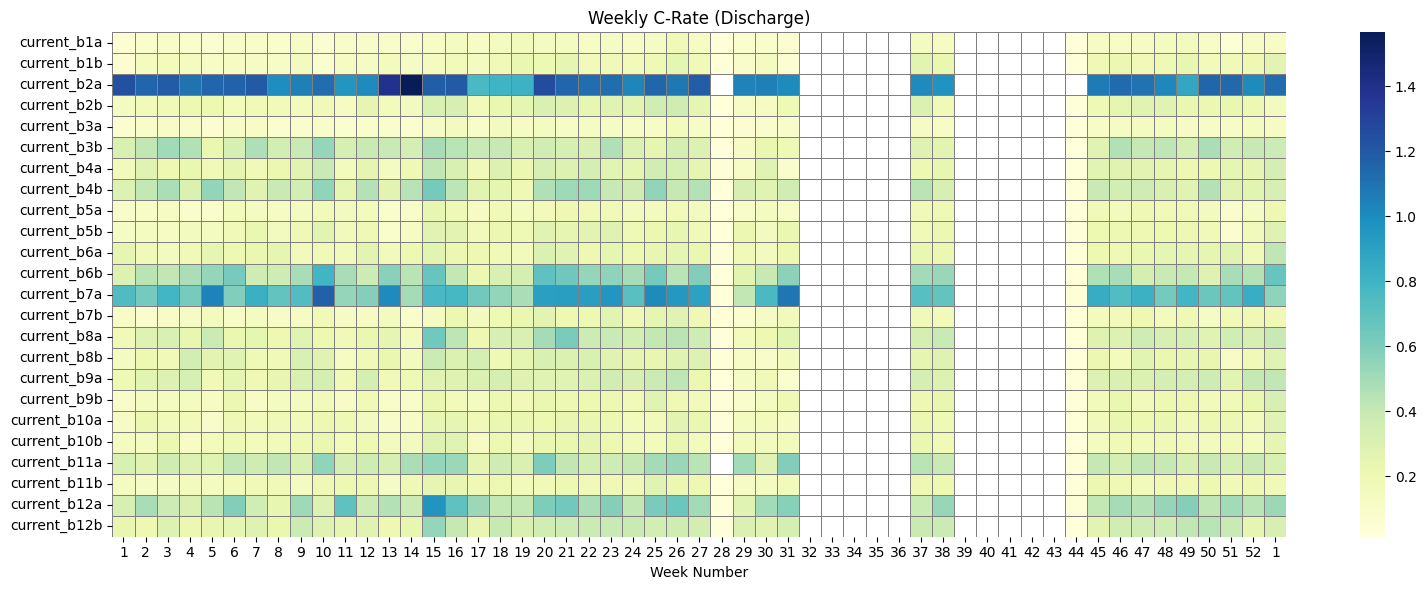

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))

crate_discharge_pack_weekly = crate_discharge_pack.resample('W-SUN').mean()

# Create heatmap
sns.heatmap(
    crate_discharge_pack_weekly.T,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    ax=ax,
    xticklabels=crate_discharge_pack_weekly.index.isocalendar().week,
    yticklabels=crate_discharge_pack_weekly.columns.str.replace('discharge_', ''),
)

ax.set_xlabel('Week Number')
ax.set_title('Weekly C-Rate (Discharge)')

plt.tight_layout()

### Voltage Imbalance between packs in a node

In [20]:
df_volts = df[bus_voltage_cols].copy()
df_volts = compute_diff_btw_packs(df_volts, battery_mapping, 'bus_voltage')
df_volts

,bus_volts_b1a,bus_volts_b1b,bus_volts_b2a,bus_volts_b2b,bus_volts_b3a,bus_volts_b3b,bus_volts_b4a,bus_volts_b4b,bus_volts_b5a,bus_volts_b5b,...,delta_bus_voltage_3,delta_bus_voltage_4,delta_bus_voltage_5,delta_bus_voltage_6,delta_bus_voltage_7,delta_bus_voltage_8,delta_bus_voltage_9,delta_bus_voltage_10,delta_bus_voltage_11,delta_bus_voltage_12
date_and_time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,366.000,365.500,365.000,365.500,365.500,363.000,360.500,359.000,358.500,358.500,...,-2.500,-1.500,0.000,0.000,0.000,0.664,0.000,0.500,1.500,-0.500
2024-01-01 00:30:00+00:00,366.000,365.500,365.000,365.500,365.500,363.000,360.500,359.000,358.500,358.500,...,-2.500,-1.500,0.000,0.000,0.000,0.832,0.000,0.500,1.549,-0.500
2024-01-01 01:00:00+00:00,366.000,365.500,365.000,365.500,365.500,363.000,360.500,359.000,358.500,358.500,...,-2.500,-1.500,0.000,0.000,-0.167,0.833,0.000,0.500,1.619,-0.500
2024-01-01 01:30:00+00:00,366.000,365.500,365.000,365.500,365.500,363.000,360.500,359.000,358.500,358.500,...,-2.500,-1.500,0.000,0.000,0.000,0.832,0.000,0.500,1.836,-0.500
2024-01-01 02:00:00+00:00,366.000,365.500,365.000,365.500,365.500,363.000,360.500,359.000,358.500,358.500,...,-2.500,-1.500,0.000,0.000,-0.001,1.000,0.000,0.500,1.501,-0.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:30:00+00:00,340.535,332.374,337.392,335.556,344.740,336.075,340.561,337.229,332.899,333.731,...,-8.665,-3.332,0.832,1.832,0.900,2.831,3.231,1.500,0.565,-0.954
2024-12-31 22:00:00+00:00,341.000,332.896,337.549,336.000,345.000,336.500,341.000,337.558,333.394,334.393,...,-8.500,-3.442,0.999,1.664,0.833,3.000,3.275,1.501,0.939,-0.540
2024-12-31 22:30:00+00:00,341.000,333.500,338.000,336.044,345.000,336.565,341.000,338.000,333.551,334.500,...,-8.435,-3.000,0.949,1.779,1.000,2.781,3.051,1.669,0.892,-0.628


### Power Stability

In [29]:
#find cycles where power in/out is not stable and very noisy
#distribute into charge and discharge

for pack in battery_packs:
    charge_pack = df[df[f'power_flow_{pack}'] < 0][f'power_flow_{pack}']
    discharge_pack = df[df[f'power_flow_{pack}'] > 0][f'power_flow_{pack}']
    df[f'charge_stability_{pack}'] = charge_pack.rolling(window=2).std() # 1hour window
    df[f'discharge_stability_{pack}'] = discharge_pack.rolling(window=2).std()

df[['power_flow_b1a', 'charge_stability_b1a']]

#the std tells us the difference between the power flow within a 1hour window, showing the variability in charge/discharge values

C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\1112993829.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'charge_stability_{pack}'] = charge_pack.rolling(window=2).std() # 1hour window
C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\1112993829.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'discharge_stability_{pack}'] = discharge_pack.rolling(window=2).std()
C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\1112993829.py:7: PerformanceWarning: DataFrame is highly fragmented.  Th

,power_flow_b1a,charge_stability_b1a
date_and_time,,
2024-01-01 00:00:00+00:00,0.257115,NaN
2024-01-01 00:30:00+00:00,0.222345,NaN
2024-01-01 01:00:00+00:00,0.254065,NaN
2024-01-01 01:30:00+00:00,0.061000,NaN
2024-01-01 02:00:00+00:00,0.181475,NaN
...,...,...
2024-12-31 21:30:00+00:00,0.135538,NaN
2024-12-31 22:00:00+00:00,0.026143,NaN
2024-12-31 22:30:00+00:00,-0.038363,0.013973


## 3. SoC Computations

In [30]:
# Compute SoC Variability Metrics
soc_data = df[soc_cols].copy()

soc_metrics = pd.DataFrame(
    {
        'pack_mean': soc_data.mean(),
        'pack_range': [ [f'{round(soc_data[col].min(),2)}-{round(soc_data[col].max(),2)}'] for col in soc_data.columns ],
    }
)

round(soc_metrics, 2)

,pack_mean,pack_range
state_of_charge_b1a,26.22,[4.1-96.71]
state_of_charge_b1b,24.07,[3.22-93.53]
state_of_charge_b2a,25.13,[3.97-95.34]
state_of_charge_b2b,25.21,[3.64-96.59]
state_of_charge_b3a,25.45,[4.0-98.02]
state_of_charge_b3b,22.14,[2.78-93.01]
state_of_charge_b4a,27.94,[3.33-95.6]
state_of_charge_b4b,26.85,[2.7-95.82]
state_of_charge_b5a,25.85,[2.74-95.96]
state_of_charge_b5b,25.44,[2.73-91.25]


### **Pack SoC Range**

{'whiskers': [<matplotlib.lines.Line2D object at 0x00000195FCA65D10>, <matplotlib.lines.Line2D object at 0x00000195FCA65E50>, <matplotlib.lines.Line2D object at 0x00000195FCA665D0>, <matplotlib.lines.Line2D object at 0x00000195FCA66710>, <matplotlib.lines.Line2D object at 0x00000195FCA66E90>, <matplotlib.lines.Line2D object at 0x00000195FCA66FD0>, <matplotlib.lines.Line2D object at 0x00000195FCA67750>, <matplotlib.lines.Line2D object at 0x00000195FCA67890>, <matplotlib.lines.Line2D object at 0x00000195FC9C4050>, <matplotlib.lines.Line2D object at 0x00000195FC9C4190>, <matplotlib.lines.Line2D object at 0x00000195FC9C4A50>, <matplotlib.lines.Line2D object at 0x00000195FC9C4B90>, <matplotlib.lines.Line2D object at 0x00000195FC9C51D0>, <matplotlib.lines.Line2D object at 0x00000195FC9C5310>, <matplotlib.lines.Line2D object at 0x00000195FC9C5A90>, <matplotlib.lines.Line2D object at 0x00000195FC9C5BD0>, <matplotlib.lines.Line2D object at 0x00000195FC9C6350>, <matplotlib.lines.Line2D object at

C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\2317516758.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = plt.boxplot([soc_data[col].dropna() for col in soc_data.columns], labels=soc_data.columns)


Text(0.5, 1.0, 'SoC range (30min) from 2024-01-01 to 2024-12-31')

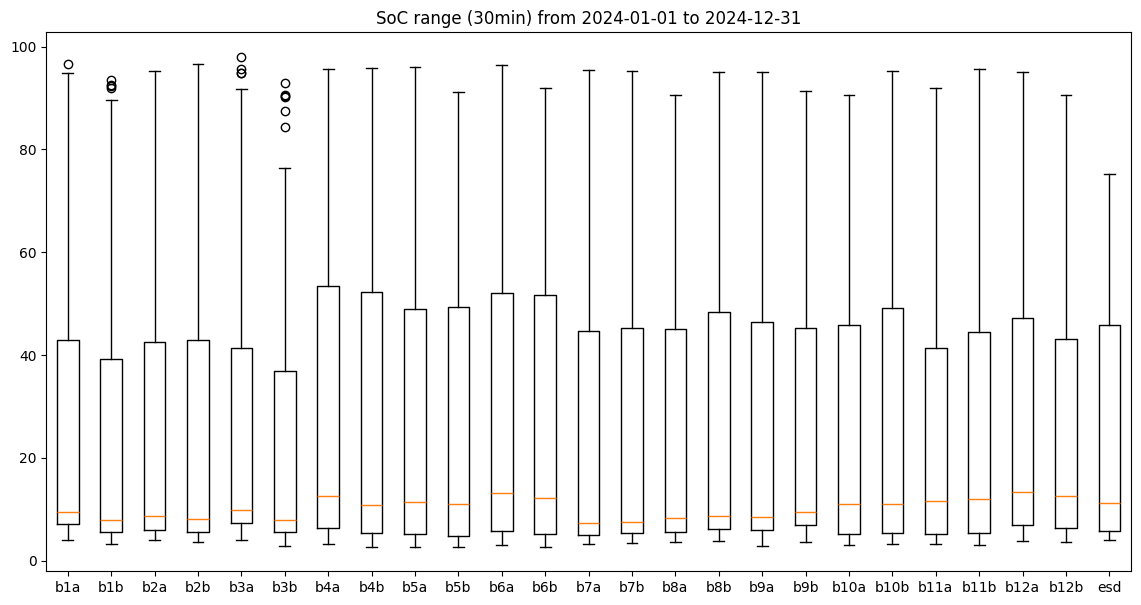

In [31]:
soc_data.columns = soc_data.columns.str.strip().str.replace('state_of_charge_', '')
plt.figure(figsize=(14,7))
result = plt.boxplot([soc_data[col].dropna() for col in soc_data.columns], labels=soc_data.columns)
print(result)
plt.title('SoC range (30min) from 2024-01-01 to 2024-12-31')

In [32]:
#compute mean for each data
soc_daily = soc_data.copy()
soc_pack = soc_daily.filter(like='b')

#nulify data when packs were possibly in fault - diff in values over days is 0 
df_filtered = soc_pack[soc_pack.diff() != 0].dropna()
diff_zero = soc_pack.diff().eq(0)

# rows where diff == 0
mask_zero = diff_zero.any(axis=1)

# also mark row before and after
mask_remove = mask_zero | mask_zero.shift(1) | mask_zero.shift(-1)

df_filtered = soc_pack[~mask_remove]

#drop these 2 rows
df_filtered.drop(df_filtered.loc['2024-07-19': '2024-09-11'].index, inplace=True)

df_filtered

,b1a,b1b,b2a,b2b,b3a,b3b,b4a,b4b,b5a,b5b,...,b8a,b8b,b9a,b9b,b10a,b10b,b11a,b11b,b12a,b12b
date_and_time,,,,,,,,,,,,,,,,,,,,,
2024-01-03 01:00:00+00:00,32.353056,31.101667,28.517778,28.274722,30.433611,27.889444,35.146944,33.298056,35.958333,35.561944,...,35.939444,39.173056,34.037222,33.185556,32.616944,34.587778,27.443611,28.820278,32.556389,30.744167
2024-01-03 01:30:00+00:00,40.729167,38.727778,41.177500,41.247222,40.796667,37.436389,49.591944,47.474444,47.104444,46.921944,...,45.189722,48.599722,42.965833,41.785278,46.382222,48.337778,39.477222,42.566944,44.136944,40.650833
2024-01-03 02:00:00+00:00,55.596667,52.706389,54.564444,55.707222,54.144444,48.845556,65.379722,65.553889,61.120000,60.361667,...,54.073889,57.719167,57.742500,56.330833,56.884722,59.431389,56.138056,62.260833,55.929722,51.390000
2024-01-03 02:30:00+00:00,64.876111,63.243333,62.366667,64.462500,66.427222,60.647500,75.725556,76.735000,75.509722,73.668056,...,66.924167,71.289167,71.605833,68.948611,70.846667,73.758056,64.527222,70.450833,67.295556,61.426111
2024-01-03 03:00:00+00:00,67.700000,65.000000,63.563056,66.300000,70.100000,64.196944,77.907500,79.209167,77.343056,75.475278,...,69.526111,73.811389,72.900000,70.564444,73.122222,76.443611,64.700000,69.000000,70.413333,64.476389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 20:00:00+00:00,13.270833,12.026111,14.289722,13.223611,10.587778,9.815000,15.923056,15.338333,12.042778,12.655000,...,9.379167,9.708333,13.013333,13.473611,13.106111,15.452500,13.805556,14.588889,15.237500,12.928889
2024-12-31 20:30:00+00:00,6.938333,5.401111,6.948333,6.359722,7.713611,6.173333,9.908611,9.754722,6.566944,8.516389,...,4.657500,5.268333,7.731944,8.845278,7.679167,10.286389,5.181389,5.108333,7.026944,6.365278
2024-12-31 21:00:00+00:00,6.141111,4.707500,5.913056,5.445556,7.315000,5.716667,7.758333,7.276111,5.730000,6.153611,...,4.200000,4.428333,6.821667,8.147500,3.937500,4.171389,4.247222,4.341667,5.653611,5.310833


### Pack Deviation over time

Daily deviation of packs from system mean SoC

Text(0, 0.5, 'SoC Diff (%)')

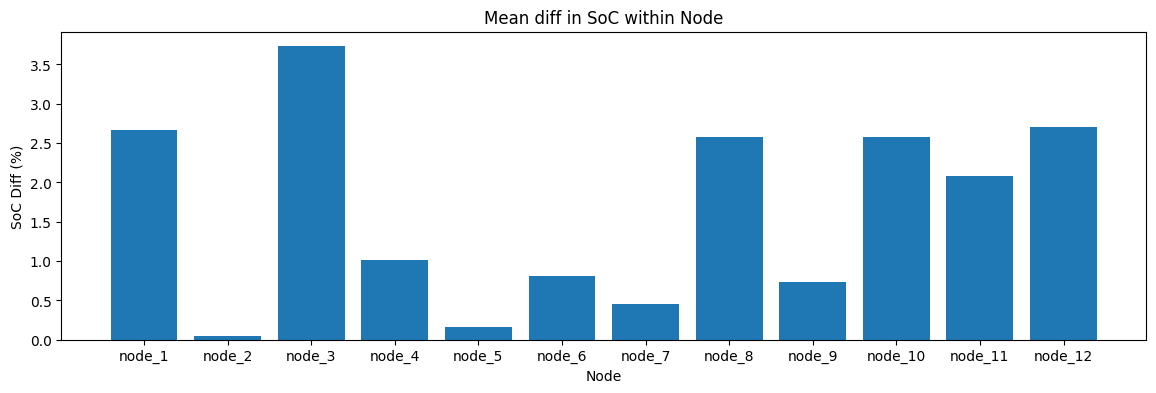

In [33]:
# Diff in SoC within nodes
delta_soc_node = compute_diff_btw_packs(df_filtered, battery_mapping, 'soc').filter(like='delta')
plt.bar(delta_soc_node.columns.str.replace('delta_soc_', 'node_'), delta_soc_node.mean().abs())
plt.title('Mean diff in SoC within Node')
plt.xlabel('Node')
plt.ylabel('SoC Diff (%)')

In [37]:
system_imbalance = soc_data.std(axis=1) #variation across packs

system_mean = soc_data.mean(axis=1)  # mean SOC of all packs at each time
pack_deviation = (soc_data.subtract(system_mean, axis=0)).abs()  # deviation from system mean

# average deviation per pack over time
avg_deviation_per_pack = pack_deviation.mean()
avg_deviation_per_pack

b1a     2.477561e+00
b1b     2.704944e+00
b2a     2.088665e+00
b2b     1.860380e+00
b3a     2.653193e+00
b3b     4.043682e+00
b4a     2.951028e+00
b4b     2.859561e+00
b5a     2.248363e+00
b5b     2.178207e+00
b6a     2.455571e+00
b6b     2.072305e+00
b7a     1.898756e+00
b7b     1.762756e+00
b8a     1.738565e+00
b8b     2.123914e+00
b9a     1.695472e+00
b9b     1.968958e+00
b10a    1.828067e+00
b10b    2.697476e+00
b11a    2.402204e+00
b11b    1.822834e+00
b12a    2.038807e+00
b12b    2.073981e+00
esd     2.911807e-15
dtype: float64


**Question**: Does charge stability (low SoC variability) correlate with better efficiency?

C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\808702673.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  soc_imbalance_2h = system_imbalance.resample('3H').mean()
C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\808702673.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aux_energy_2h = df['energy_services'].resample('3H').mean()


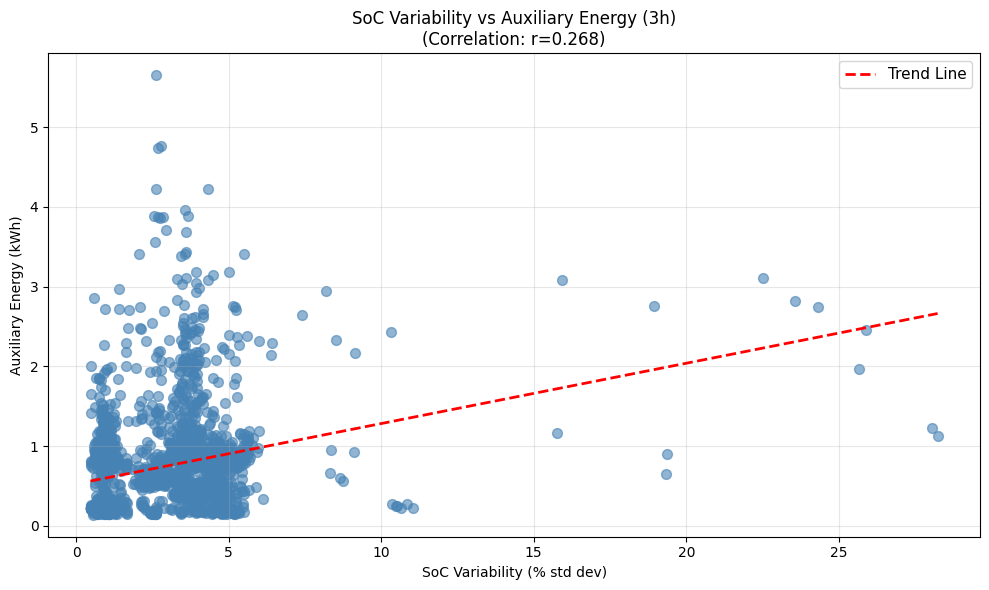

In [38]:
#SoC Variability vs Aux Energy
# resample to 2-hour to reduce noise
soc_imbalance_2h = system_imbalance.resample('3H').mean()
aux_energy_2h = df['energy_services'].resample('3H').mean()

# Create correlation dataframe
corr_df = pd.concat([soc_imbalance_2h, aux_energy_2h], axis=1).dropna()
corr_df = corr_df.rename(columns={0: 'soc_variability', 'energy_services': 'aux_energy'})

# Calculate correlation
correlation = corr_df['soc_variability'].corr(corr_df['aux_energy'])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_df['soc_variability'], corr_df['aux_energy'], alpha=0.6, s=50, color='steelblue')

# Trend line
z = np.polyfit(corr_df['soc_variability'], corr_df['aux_energy'], 1)
p = np.poly1d(z)
x_trend = np.linspace(corr_df['soc_variability'].min(), corr_df['soc_variability'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line')

ax.set_xlabel('SoC Variability (% std dev)')
ax.set_ylabel('Auxiliary Energy (kWh)')
ax.set_title(f'SoC Variability vs Auxiliary Energy (3h)\n(Correlation: r={correlation:.3f})')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

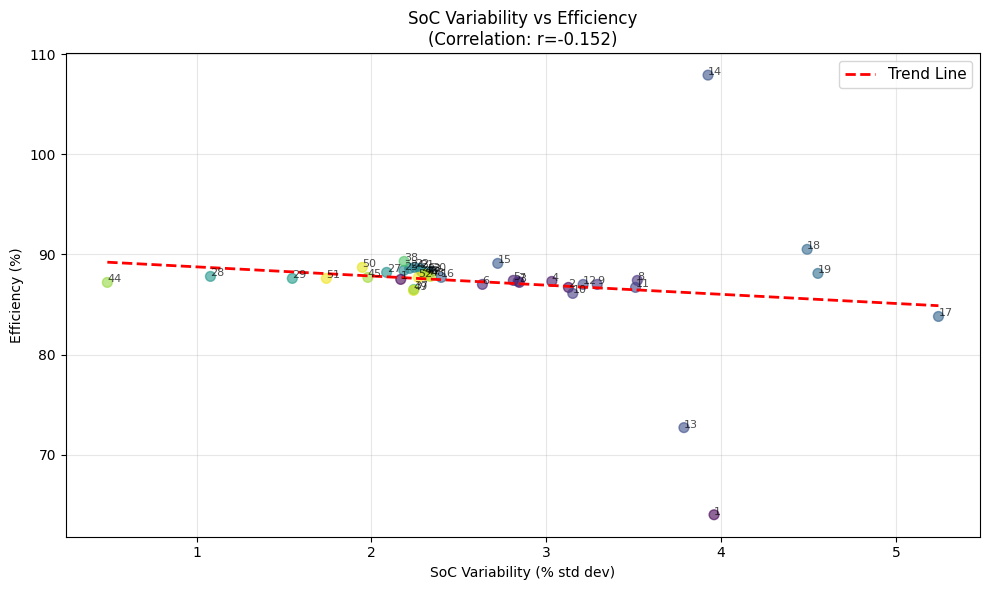

In [39]:
#color points on time(week)

#SoC Variability vs Efficiency
# resample to 2-hour to reduce noise
soc_imbalance_weekly = system_imbalance.resample('W-SUN').mean()

# Create correlation dataframe
corr_df = pd.concat([soc_imbalance_weekly, df_weekly['efficiency']], axis=1).dropna()
corr_df = corr_df.rename(columns={0: 'soc_variability'})
corr_df['week_num'] = corr_df.index.isocalendar().week

# Calculate correlation
correlation = corr_df['soc_variability'].corr(corr_df['efficiency'])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_df['soc_variability'], corr_df['efficiency'], alpha=0.6, s=50, c=corr_df['week_num'],cmap='viridis')

# Trend line
z = np.polyfit(corr_df['soc_variability'], corr_df['efficiency'], 1)
p = np.poly1d(z)
x_trend = np.linspace(corr_df['soc_variability'].min(), corr_df['soc_variability'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line')

ax.set_xlabel('SoC Variability (% std dev)')
ax.set_ylabel('Efficiency (%)')
ax.set_title(f'SoC Variability vs Efficiency\n(Correlation: r={correlation:.3f})')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# annotate week num on marker
for i, txt in enumerate(corr_df['week_num']):
    ax.annotate(
        txt,
        (corr_df['soc_variability'].iloc[i],
         corr_df['efficiency'].iloc[i]),
        fontsize=8,
        alpha=0.7
    )

plt.tight_layout()
plt.show()

### C-rate vs Efficiency (ESD)


Text(0.5, 1.0, 'Correlation: Charge C-rate vs Efficiency')

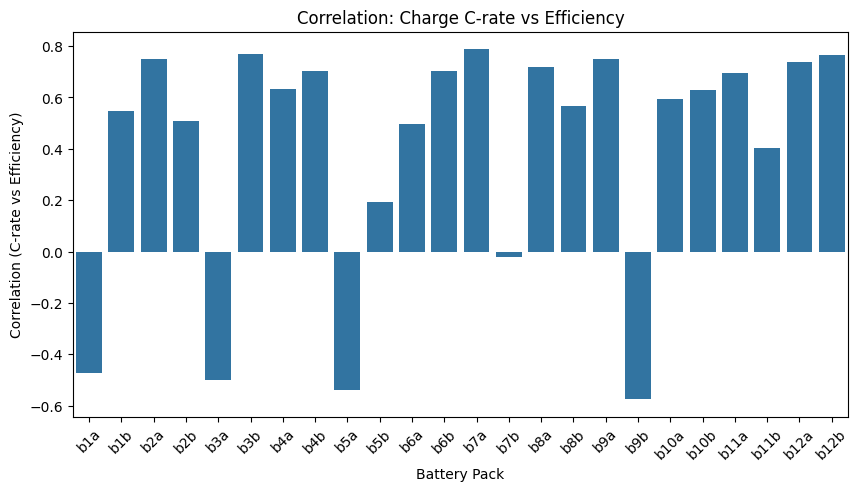

In [41]:
#Crate(charge) vs Efficiency
crate_weekly = crate_charge_pack.resample('W-SUN').mean(1)

corr_data = []

for pack in battery_packs:
    df_pack = pd.concat([crate_weekly[f'current_{pack}'], df_weekly[f'efficiency_{pack}']],axis=1).dropna()
    corr = df_pack.corr().iloc[0,1]
    corr_data.append(corr)

corr_df = pd.DataFrame({
    'Battery Pack': battery_packs,
    'Correlation (C-rate vs Efficiency)': corr_data
})

plt.figure(figsize=(10,5))
sns.barplot(data=corr_df,
            x='Battery Pack',
            y='Correlation (C-rate vs Efficiency)')
plt.xticks(rotation=45)
plt.title('Correlation: Charge C-rate vs Efficiency')

Text(0.5, 1.0, 'Correlation: Discharge C-rate vs Efficiency')

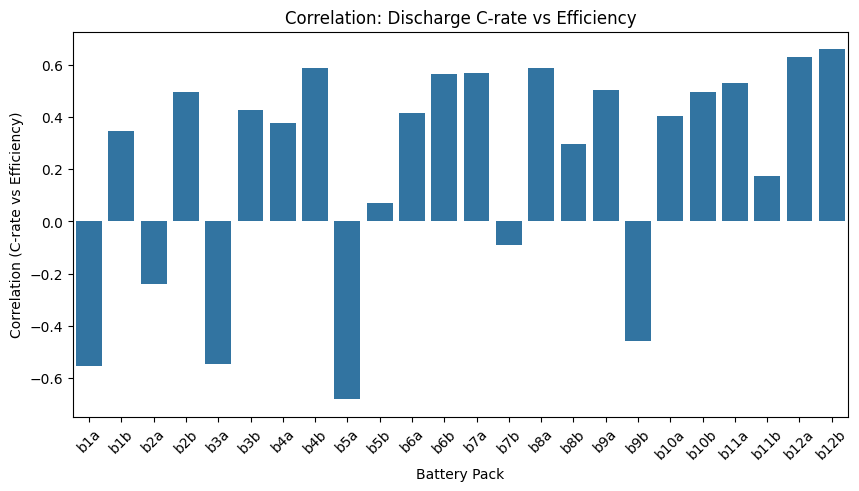

In [42]:
#Crate(discharge) vs Efficiency
crate_weekly = crate_discharge_pack.resample('W-SUN').mean(1)

corr_data = []

for pack in battery_packs:
    df_pack = pd.concat([crate_weekly[f'current_{pack}'], df_weekly[f'efficiency_{pack}']],axis=1).dropna()
    corr = df_pack.corr().iloc[0,1]
    corr_data.append(corr)

corr_df = pd.DataFrame({
    'Battery Pack': battery_packs,
    'Correlation (C-rate vs Efficiency)': corr_data
})

plt.figure(figsize=(10,5))
sns.barplot(data=corr_df,
            x='Battery Pack',
            y='Correlation (C-rate vs Efficiency)')
plt.xticks(rotation=45)
plt.title('Correlation: Discharge C-rate vs Efficiency')

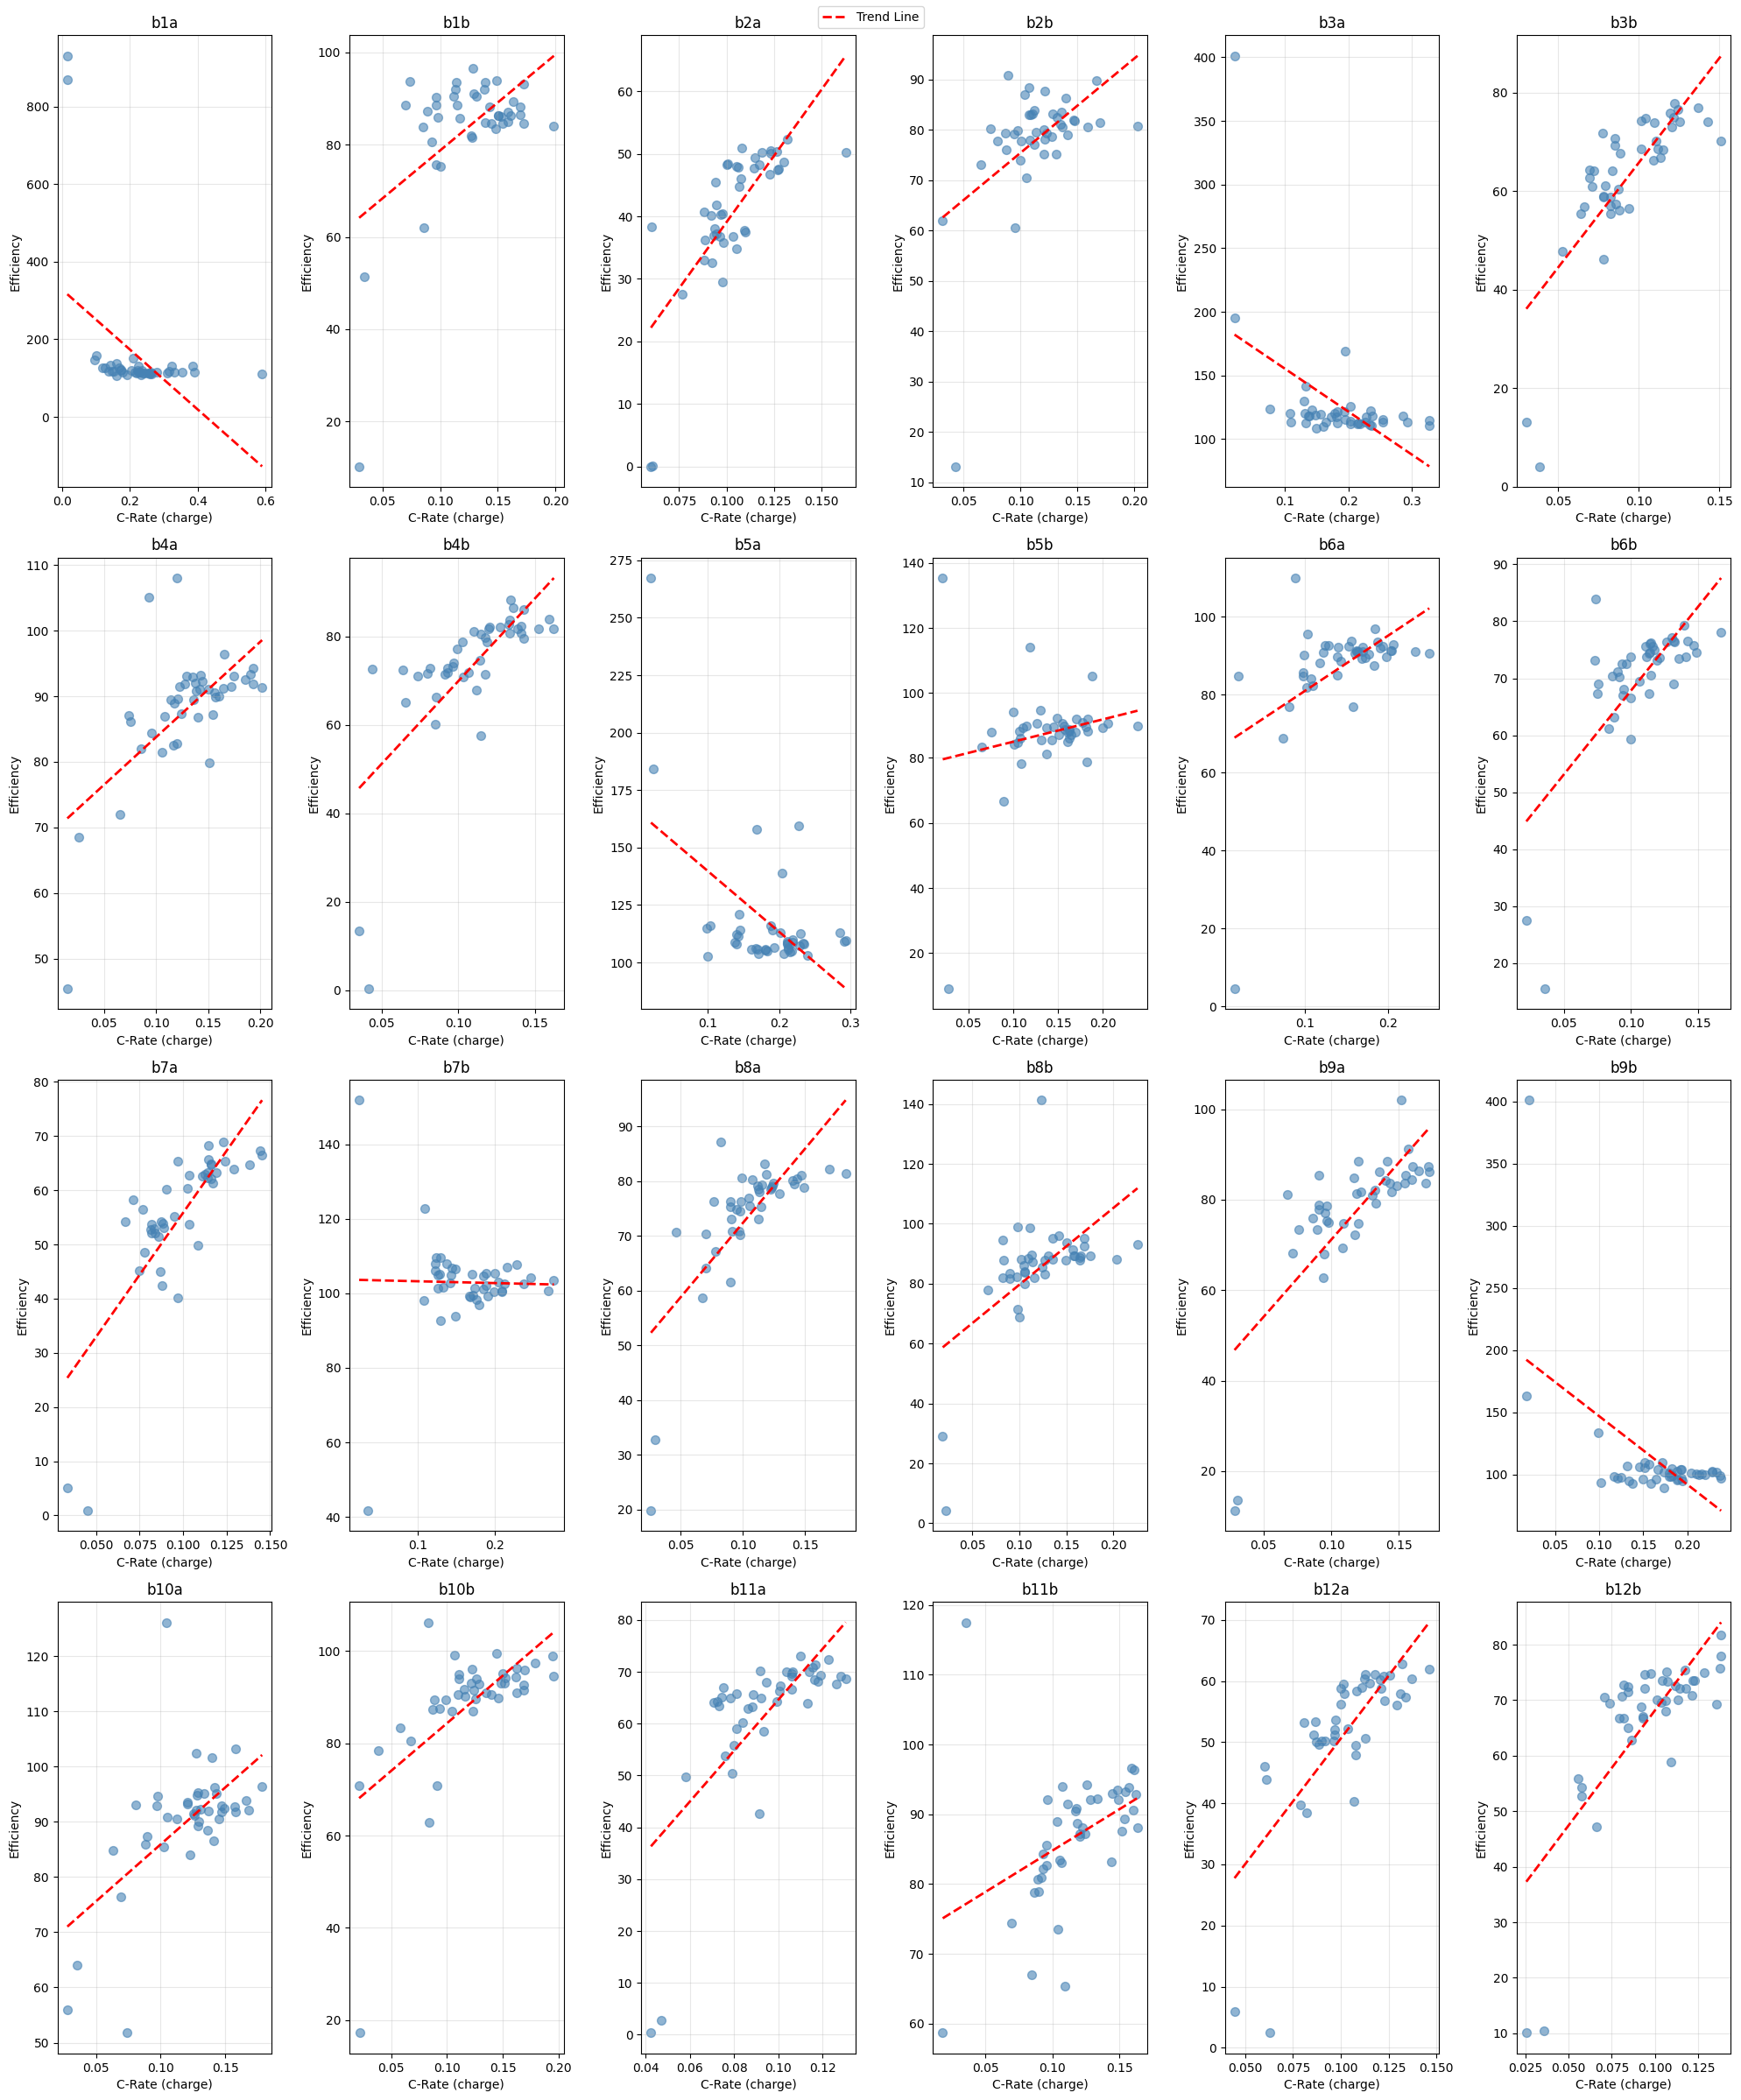

In [43]:
fig, ax = plt.subplots(4, 6, figsize=(20, 24))
ax = ax.flatten()

crate_charge_weekly = crate_charge_pack.resample('W-SUN').mean(1)
crate_discharge_weekly = crate_discharge_pack.resample('W-SUN').mean(1)


for i, pack in enumerate(battery_packs):
    df_pack = pd.concat([crate_charge_weekly[f'current_{pack}'], df_weekly[f'efficiency_{pack}']],axis=1).dropna()
    correlation = df_pack.corr().iloc[0,1]
    x = f'current_{pack}'
    y = f'efficiency_{pack}'
    ax[i].scatter(df_pack[x], df_pack[y], alpha=0.6, s=50, color='steelblue')

    # Trend line
    z = np.polyfit(df_pack[x], df_pack[y], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_pack[x].min(), df_pack[x].max(), 100)
    ax[i].plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line')

    ax[i].set_xlabel(f'C-Rate (charge)')
    ax[i].set_ylabel(f'Efficiency')
    # ax[i].set_title(f'{x.capitalize()} vs {y.capitalize()}\n(Correlation: r={correlation:.3f})')
    ax[i].grid(True, alpha=0.3)
    # ax[i].legend(fontsize=11)
    ax[i].set_title(pack)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
)
plt.tight_layout()
plt.show()


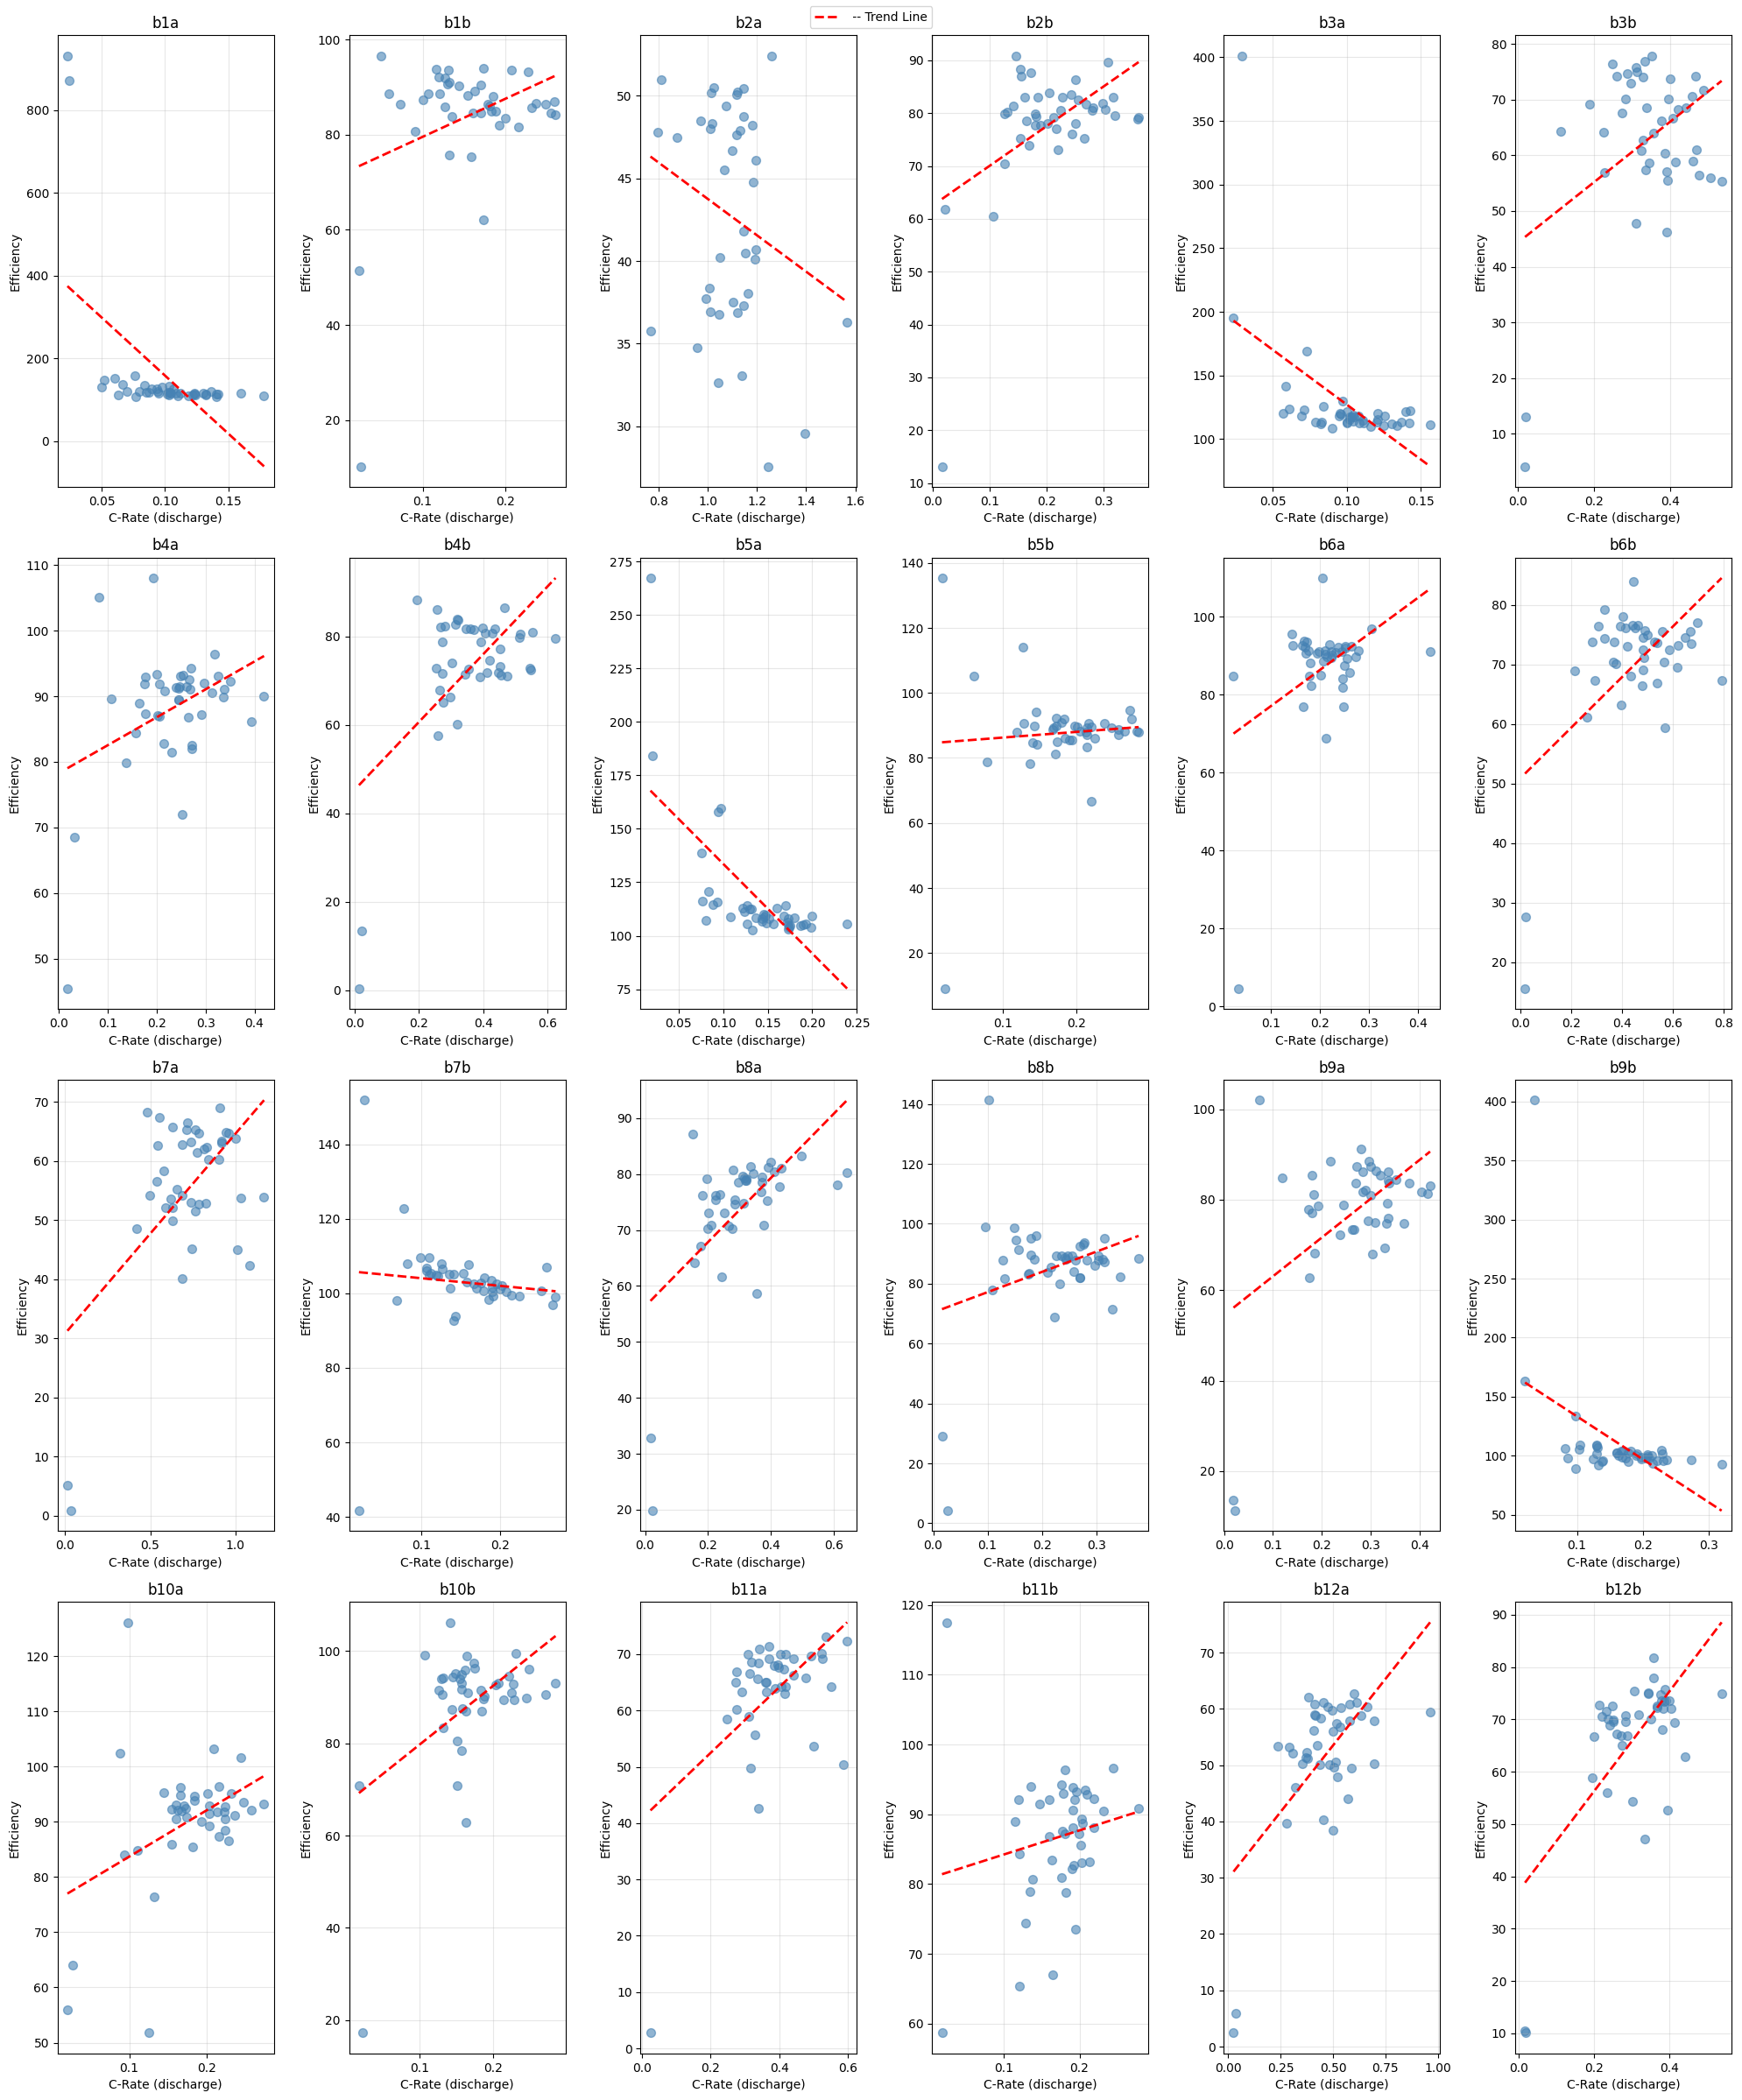

In [44]:
crate_discharge_weekly = crate_discharge_pack.resample('W-SUN').mean(1)

fig, ax = plt.subplots(4, 6, figsize=(20, 24))
ax = ax.flatten()
for i, pack in enumerate(battery_packs):
    df_pack = pd.concat([crate_discharge_weekly[f'current_{pack}'], df_weekly[f'efficiency_{pack}']],axis=1).dropna()
    correlation = df_pack.corr().iloc[0,1]
    x = f'current_{pack}'
    y = f'efficiency_{pack}'
    ax[i].scatter(df_pack[x], df_pack[y], alpha=0.6, s=50, color='steelblue')

    # Trend line
    z = np.polyfit(df_pack[x], df_pack[y], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_pack[x].min(), df_pack[x].max(), 100)
    ax[i].plot(x_trend, p(x_trend), "r--", linewidth=2, label=' -- Trend Line')
    ax[i].set_xlabel(f'C-Rate (discharge)')
    ax[i].set_ylabel(f'Efficiency')
    # ax[i].set_title(f'{x.capitalize()} vs {y.capitalize()}\n(Correlation: r={correlation:.3f})')
    ax[i].grid(True, alpha=0.3)
    # ax[i].legend(fontsize=11)
    ax[i].set_title(pack)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
)
plt.tight_layout()
plt.show()


### Cell Volts Imbalance

In [46]:
df[cell_voltage_cols].describe()

,delta_cell_volts_b1a,delta_cell_volts_b1b,delta_cell_volts_b2a,delta_cell_volts_b2b,delta_cell_volts_b3a,delta_cell_volts_b3b,delta_cell_volts_b4a,delta_cell_volts_b4b,delta_cell_volts_b5a,delta_cell_volts_b5b,...,delta_cell_volts_b8a,delta_cell_volts_b8b,delta_cell_volts_b9a,delta_cell_volts_b9b,delta_cell_volts_b10a,delta_cell_volts_b10b,delta_cell_volts_b11a,delta_cell_volts_b11b,delta_cell_volts_b12a,delta_cell_volts_b12b
count,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,...,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000,13766.000000
mean,0.067700,0.068444,0.060318,0.057647,0.059311,0.063502,0.084472,0.087638,0.076210,0.099344,...,0.065041,0.060871,0.073594,0.065156,0.068411,0.071689,0.075658,0.063717,0.063646,0.075413
std,0.045236,0.043752,0.039819,0.036074,0.037249,0.039038,0.056214,0.058048,0.050026,0.065781,...,0.042611,0.038834,0.051320,0.041464,0.043446,0.044426,0.047823,0.039968,0.041407,0.049616
min,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.013278,0.010000,0.016611,...,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000
25%,0.020000,0.022222,0.020000,0.020000,0.020000,0.020000,0.028528,0.027778,0.021833,0.030000,...,0.020000,0.020000,0.020000,0.021722,0.020500,0.025361,0.024917,0.020333,0.020083,0.023944
50%,0.090125,0.089889,0.080000,0.070083,0.076639,0.079958,0.075111,0.080000,0.073458,0.096583,...,0.080000,0.076639,0.098292,0.083361,0.066847,0.074069,0.074653,0.064250,0.061431,0.075778
75%,0.110000,0.110000,0.100000,0.090000,0.090000,0.099444,0.140000,0.140000,0.120000,0.160000,...,0.102625,0.099639,0.120000,0.101139,0.110000,0.110000,0.120000,0.100000,0.100000,0.120000
max,0.174444,0.189250,0.139028,0.145306,0.134889,0.157750,0.218917,0.222139,0.201583,0.245000,...,0.154361,0.144556,0.192028,0.163167,0.163194,0.160361,0.179750,0.148444,0.163167,0.199694


<Axes: xlabel='date_and_time'>

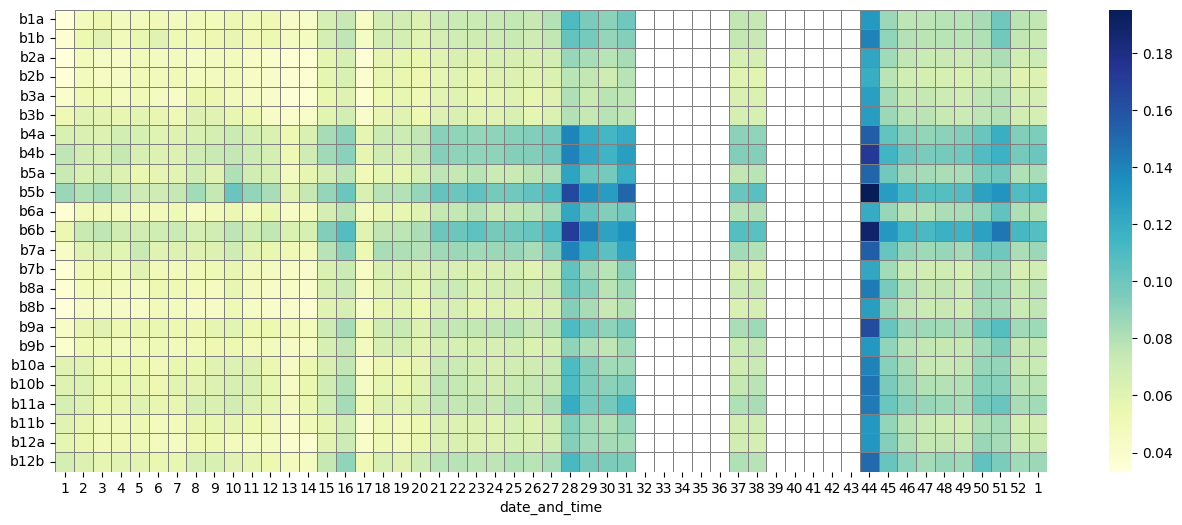

In [47]:
cell_volts_weekly = df[cell_voltage_cols].resample('W-Sun').mean()

plt.figure(figsize=(16,6))
sns.heatmap(
    cell_volts_weekly.T,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    xticklabels=cell_volts_weekly.index.isocalendar().week,
    yticklabels=cell_voltage_cols.str.replace('delta_cell_volts_', '')
)

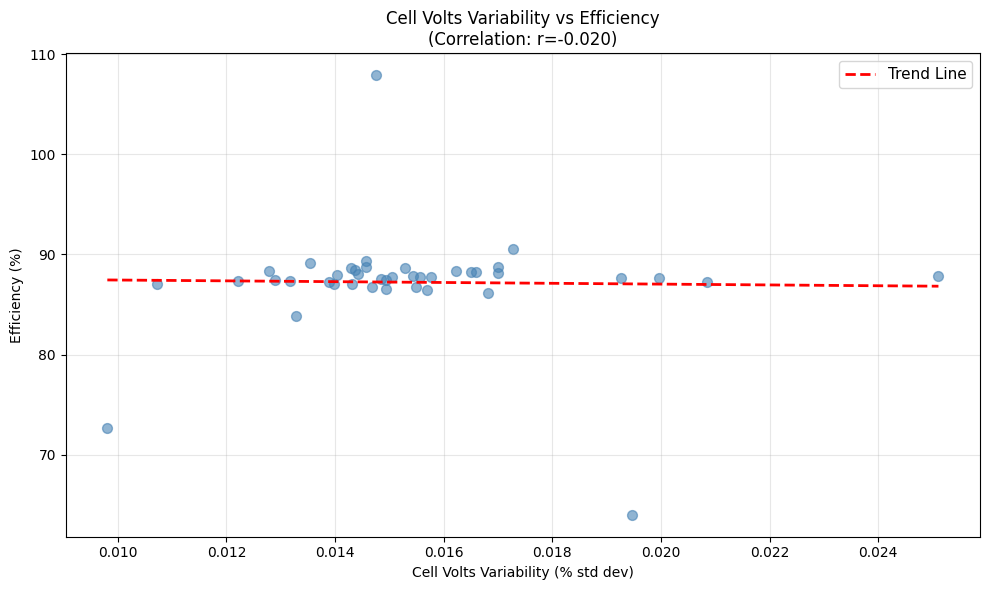

In [48]:
##cell volts imbalance
cell_volts_imbalance = df[cell_voltage_cols].std(axis=1)
#Cell volts Variability vs Efficiency
cell_volts_imbalance_weekly = cell_volts_imbalance.resample('W-SUN').mean()
cell_volts_max_weekly = cell_volts_imbalance.resample('W-SUN').max()

# Create correlation dataframe
corr_df = pd.concat([cell_volts_imbalance_weekly, df_weekly['efficiency']], axis=1).dropna()
corr_df = corr_df.rename(columns={0: 'cell_volts_variability'})

# Calculate correlation
correlation = corr_df['cell_volts_variability'].corr(corr_df['efficiency'])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_df['cell_volts_variability'], corr_df['efficiency'], alpha=0.6, s=50, color='steelblue')

# Trend line
z = np.polyfit(corr_df['cell_volts_variability'], corr_df['efficiency'], 1)
p = np.poly1d(z)
x_trend = np.linspace(corr_df['cell_volts_variability'].min(), corr_df['cell_volts_variability'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line')

ax.set_xlabel('Cell Volts Variability (% std dev)')
ax.set_ylabel('Efficiency (%)')
ax.set_title(f'Cell Volts Variability vs Efficiency\n(Correlation: r={correlation:.3f})')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Long Term Trends - SoH

To look at correlation of system operations with SoH, we need to look at data from beginning

In [50]:
df_3yrs = pd.read_csv('system_data_3yrs.csv')
df_3yrs['date_and_time'] = pd.to_datetime(df_3yrs['date_and_time'])
df_3yrs = df_3yrs.set_index('date_and_time')

In [52]:
weekly_df = (
    df_3yrs
    .groupby('system_id')[['charge_esd', 'discharge_esd']]
    .resample('MS')
    .sum()
    .reset_index()
)

weekly_df['efficiency'] = ((weekly_df['discharge_esd']/weekly_df['charge_esd'].abs())*100).replace([np.inf, -np.inf], np.nan)
weekly_df = weekly_df[weekly_df['efficiency'] <= 150]
weekly_df= weekly_df[weekly_df['efficiency'] != 0]

Text(0.5, 1.0, 'Weekly System Efficiency')

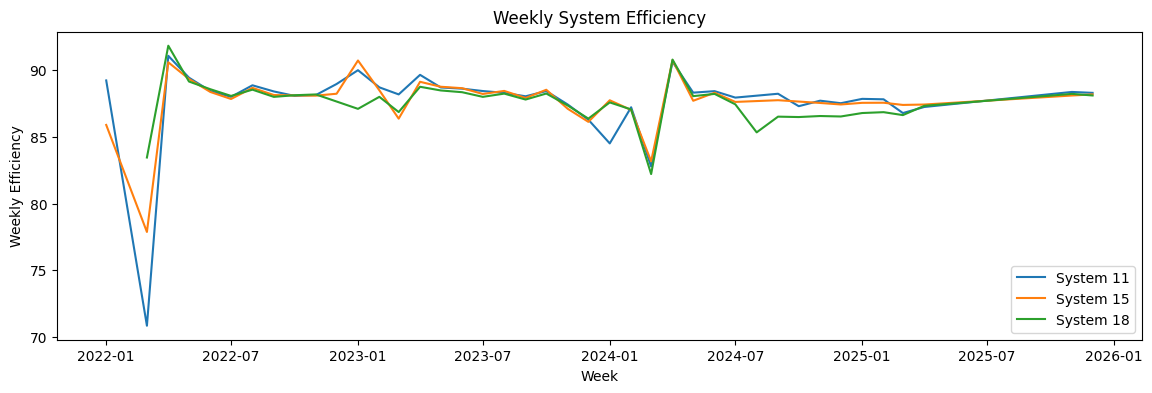

In [53]:
filtered_df = weekly_df[weekly_df['system_id'].isin([11,15,18])]
for sid, group in filtered_df.groupby('system_id'):
    plt.plot(group['date_and_time'], group['efficiency'], label=f'System {sid}')

plt.legend()
plt.ylabel('Weekly Efficiency')
plt.xlabel('Week')
plt.title('Weekly System Efficiency')

Text(0.5, 1.0, 'Weekly System Efficiency')

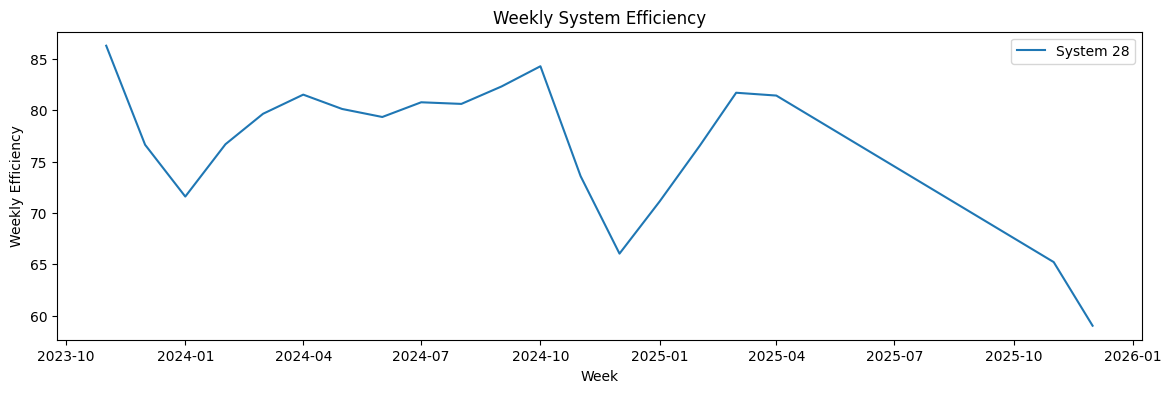

In [54]:
filtered_df = weekly_df[weekly_df['system_id'].isin([28])]
for sid, group in filtered_df.groupby('system_id'):
    plt.plot(group['date_and_time'], group['efficiency'], label=f'System {sid}')

plt.legend()
plt.ylabel('Weekly Efficiency')
plt.xlabel('Week')
plt.title('Weekly System Efficiency')

### Extreme SoC Bands

In [56]:
soc_pack_df = df_3yrs.filter(regex=r'^state_of_charge_b\d+')
#nulify data when packs were possibly in fault - diff in values over days is 0 
df_filtered = soc_pack_df[soc_pack_df.diff() != 0].dropna(how='all')
diff_zero = soc_pack_df.diff().eq(0)

# rows where diff == 0
mask_zero = diff_zero.any(axis=1)

# also mark row before and after
mask_remove = mask_zero | mask_zero.shift(1) | mask_zero.shift(-1)

df_filtered = soc_pack_df[~mask_remove]
df_filtered

,state_of_charge_b1a,state_of_charge_b1b,state_of_charge_b2a,state_of_charge_b2b,state_of_charge_b3a,state_of_charge_b3b,state_of_charge_b4a,state_of_charge_b4b,state_of_charge_b5a,state_of_charge_b5b,...,state_of_charge_b8a,state_of_charge_b8b,state_of_charge_b9a,state_of_charge_b9b,state_of_charge_b10a,state_of_charge_b10b,state_of_charge_b11a,state_of_charge_b11b,state_of_charge_b12a,state_of_charge_b12b
date_and_time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,43.138600,43.199913,49.198929,54.388270,51.354745,48.238565,56.644861,58.069884,58.716939,50.768889,...,50.202419,50.206962,52.756348,50.945289,57.179097,59.602760,57.259826,53.772703,51.972483,52.100399
2022-01-05 00:00:00+00:00,24.458491,24.288858,20.067420,23.067824,26.844771,26.040402,22.444549,23.367132,31.303887,26.702377,...,23.598095,24.145800,23.059097,22.259396,22.407361,24.713855,26.292052,23.414798,25.461522,27.321803
2022-01-06 00:00:00+00:00,27.512824,27.421326,22.285928,25.494923,25.981333,25.004629,27.027005,27.977919,31.895536,27.065751,...,24.060422,24.411270,27.240300,26.699694,27.817945,30.086640,31.225878,27.644764,24.693500,26.122059
2022-01-07 00:00:00+00:00,32.806910,33.076245,35.171411,39.592857,37.529020,35.483230,43.429516,44.658437,43.330332,36.975125,...,37.101563,37.148851,42.758391,41.729784,40.461423,43.132181,42.973388,39.126303,37.388052,38.493207
2022-01-08 00:00:00+00:00,19.601001,20.067124,22.216591,25.340255,22.500920,22.243924,34.765613,35.697986,33.801510,29.446655,...,22.208623,22.159404,27.607656,26.897020,32.109647,34.159311,34.603113,31.563044,31.666921,32.216146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,71.077164,74.548414,73.794462,69.438299,74.277569,69.545104,72.494207,65.194722,69.929520,72.118582,...,70.445885,73.878177,70.150729,72.036997,73.593744,67.556580,72.438356,72.577778,71.040174,72.521094
2025-12-28 00:00:00+00:00,50.644803,56.241933,56.860775,52.087442,55.526487,49.590613,56.635810,45.469809,48.813906,55.050017,...,50.291013,55.947407,48.054693,55.758733,55.822766,47.097101,53.864097,53.190561,51.744948,53.950561
2025-12-29 00:00:00+00:00,63.985770,67.760006,67.451279,63.004994,67.202164,61.949039,65.147685,55.574711,59.865787,63.906175,...,62.228640,66.414572,60.835289,65.850075,68.238912,60.784809,63.171244,62.704913,63.824543,65.482986


In [57]:
max_soc = 90
min_soc = 10

#drop these 2 rows
# df_filtered.drop(df_filtered.loc['2024-07-19': '2024-09-11'].index, inplace=True)
soc_lower_df = df_filtered[(df_filtered < min_soc)]
soc_lower_df.dropna(how='all', inplace=True)
soc_higher_df = df_filtered[(df_filtered > max_soc)]
soc_higher_df.dropna(how='all', inplace=True)

df_extremes = df_filtered[(df_filtered > max_soc) | (df_filtered < min_soc)]
df_extremes.dropna(how='all', inplace=True)
round(df_extremes)

,state_of_charge_b1a,state_of_charge_b1b,state_of_charge_b2a,state_of_charge_b2b,state_of_charge_b3a,state_of_charge_b3b,state_of_charge_b4a,state_of_charge_b4b,state_of_charge_b5a,state_of_charge_b5b,...,state_of_charge_b8a,state_of_charge_b8b,state_of_charge_b9a,state_of_charge_b9b,state_of_charge_b10a,state_of_charge_b10b,state_of_charge_b11a,state_of_charge_b11b,state_of_charge_b12a,state_of_charge_b12b
date_and_time,,,,,,,,,,,,,,,,,,,,,
2022-05-28 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-29 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 00:00:00+00:00,8.0,7.0,6.0,7.0,6.0,6.0,7.0,7.0,9.0,6.0,...,8.0,8.0,8.0,8.0,7.0,8.0,8.0,5.0,5.0,7.0
2022-06-11 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-12 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-15 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.0,NaN,NaN
2024-10-16 00:00:00+00:00,NaN,NaN,9.0,8.0,NaN,NaN,9.0,5.0,NaN,NaN,...,3.0,3.0,NaN,NaN,7.0,5.0,7.0,7.0,10.0,10.0
2025-03-30 00:00:00+00:00,NaN,92.0,91.0,NaN,92.0,NaN,NaN,NaN,NaN,NaN,...,NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
df_quarterly = df_extremes.resample('QS').count()*0.5
df_quarterly['quarter'] = df_quarterly.index.to_period('Q')
df_quarterly

soc_lower_quarterly = soc_lower_df.resample('QS').count()*0.5
soc_lower_quarterly['quarter'] = soc_lower_quarterly.index.to_period('Q')

soc_higher_quarterly = soc_higher_df.resample('QS').count()*0.5
soc_higher_quarterly['quarter'] = soc_higher_quarterly.index.to_period('Q')

C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\4098511638.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_quarterly['quarter'] = df_quarterly.index.to_period('Q')
C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\4098511638.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  soc_lower_quarterly['quarter'] = soc_lower_quarterly.index.to_period('Q')
C:\Users\shreya.maliwal\AppData\Local\Temp\ipykernel_29704\4098511638.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  soc_higher_quarterly['quarter'] = soc_higher_quarterly.index.to_period('Q')


In [ ]:
soh_pack_df['quarter'] = pd.to_datetime(soh_pack_df['date_test']).dt.to_period('Q')
# join on quarter and plot each point
pack_corr_df = pd.DataFrame({
    'unit': soh_pack_df['unit'],
    'quarter': soh_pack_df['quarter'],
    'percent_capacity': soh_pack_df['percent_capacity_first_life']
})

pack_merged_df = []

for pack in battery_packs:
    pack_quarterly = df_quarterly[[f'state_of_charge_{pack}', 'quarter']]
    pack_quarterly = pack_quarterly.rename(columns={f'state_of_charge_{pack}': 'soc_extreme_hours'})
    pack_quarterly = pack_quarterly.reset_index(drop=True)
    merged_df = pd.merge(pack_quarterly, pack_corr_df[pack_corr_df['unit'] == f'{pack}'], on='quarter', how='left')
    merged_df = merged_df.fillna(0)
    #merged_df drop rows where extreme_coutn is 0 and percent_capacity is 0
    merged_df = merged_df[~((merged_df['soc_extreme_hours'] == 0) & (merged_df['percent_capacity'] == 0))]
    pack_merged_df.append(merged_df)
    # plt.figure(figsize=(10, 6))
    # plt.scatter(merged_df['soc_extreme_hours'], merged_df['percent_capacity'], color='blue')
    # plt.xlabel('Quarterly Count of SoC Extremes')
    # plt.ylabel('Percent Capacity at First Life (%)')
    # plt.title(f'Pack {pack}: SoC Extremes vs Percent Capacity')
    # plt.grid(True)
    # plt.show()
pack_merged_df = pd.concat(pack_merged_df, axis=0)
pack_merged_df.reset_index(drop=True, inplace=True)

In [60]:
battery_mapping['unit'] = 'b' + battery_mapping['position']
pack_merged_df = pack_merged_df.merge(
    battery_mapping[['node', 'unit']],
    on='unit',  # keeps all rows, fills NaN if no match
)
pack_merged_df

,soc_extreme_hours,quarter,unit,percent_capacity,node
0,5.5,2022Q2,b1a,60.43,1
1,14.0,2022Q4,b1a,59.93,1
2,14.0,2022Q4,b1a,59.72,1
3,14.0,2022Q4,b1a,59.15,1
4,26.5,2023Q2,b1a,55.09,1
...,...,...,...,...,...
259,1.5,2023Q3,b12b,61.25,12
260,3.0,2024Q2,b12b,57.44,12
261,3.0,2024Q2,b12b,44.35,12
262,3.0,2024Q2,b12b,44.15,12


In [ ]:
# fig, ax = plt.subplots(4, 3, figsize=(28, 16))
# ax = ax.flatten()

# for i, node in enumerate(pack_merged_df['node'].unique()):
#     ax1=ax[i]
#     ax2= ax1.twinx()
#     df_node = pack_merged_df.query(f"node == {node}")[['soc_extreme_hours', 'percent_capacity', 'quarter', 'unit']]
#     df_node = df_node.sort_values('quarter')
#     df_node['quarter_str'] = df_node['quarter'].astype(str)
    
#     units = df_node['unit'].unique()
#     colors = ['tab:orange', 'tab:green', 'tab:purple', 'tab:red',]  # Extend if more units
    
#     for j, unit in enumerate(units):
#         df_unit = df_node[df_node['unit'] == unit]

#         # Plot SoC extreme hours
#         ax1.plot(df_unit['quarter_str'], df_unit['soc_extreme_hours'], 
#                  marker='o', label=f'{unit} ', color=colors[j], linestyle='-')

#         # Plot percent capacity on secondary y-axis
#         ax2.plot(df_unit['quarter_str'], df_unit['percent_capacity'], 
#                  marker='s', label=f'{unit}', color=colors[j], linestyle='--')

#         # Labels and titles
#         ax1.set_ylabel('Time at Extreme SoC (hours)', color='tab:orange')
#         ax2.set_ylabel('System SoH (%)', color='tab:green')
#         ax1.legend(loc='upper right')


#     ax[i].set_title(f'Node {node}')

# plt.tight_layout()

In [62]:
#internal resistance
# current_threshold = 0.01  # adjust based on system scale
resistance_df = df.filter(regex=r'^current|^bus_volts').copy()

for pack in battery_packs:
    valid_current = resistance_df[f'current_{pack}'].abs()
    resistance_df[f"dI_{pack}"] = valid_current.diff()
    resistance_df[f"dV_{pack}"] = resistance_df[f"bus_volts_{pack}"].diff()

    threshold = 5  # A change threshold

    step_events = resistance_df[resistance_df[f"dI_{pack}"].abs() > threshold]

    #estimate of pack internal resistance calculated at moments where current changes sharply.
    df_3yrs[f"resistance_estimate_{pack}"] = step_events[f"dV_{pack}"] / step_events[f"dI_{pack}"]

df.filter(like='resistance')

,resistance_estimate_b1a,resistance_estimate_b1b,resistance_estimate_b2a,resistance_estimate_b2b,resistance_estimate_b3a,resistance_estimate_b3b,resistance_estimate_b4a,resistance_estimate_b4b,resistance_estimate_b5a,resistance_estimate_b5b,...,resistance_estimate_b8a,resistance_estimate_b8b,resistance_estimate_b9a,resistance_estimate_b9b,resistance_estimate_b10a,resistance_estimate_b10b,resistance_estimate_b11a,resistance_estimate_b11b,resistance_estimate_b12a,resistance_estimate_b12b
date_and_time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 22:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Correlation: Internal Resistance vs Efficiency')

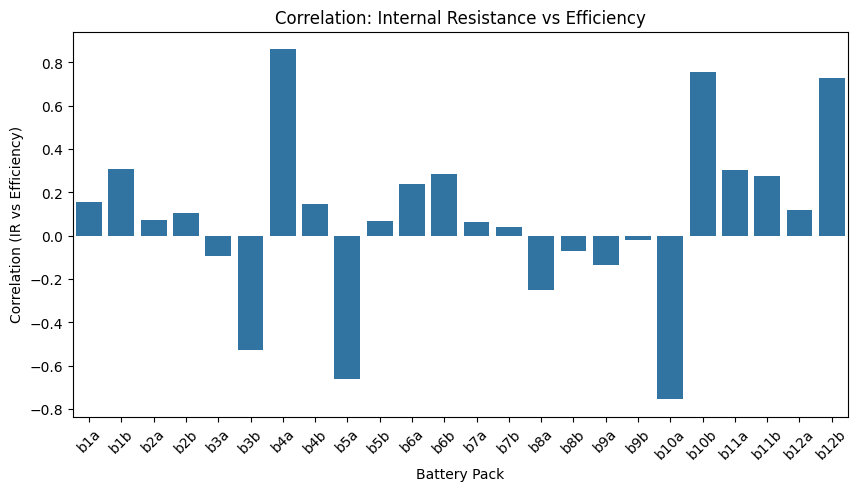

In [64]:
df_resistance = df.filter(like='resistance').resample('W-SUN').sum()
corr_data = []

for pack in battery_packs:
    df_pack = pd.concat([df_resistance[f'resistance_estimate_{pack}'], df_weekly[f'efficiency_{pack}']],axis=1).dropna()
    corr = df_pack.corr().iloc[0,1]
    corr_data.append(corr)

corr_df = pd.DataFrame({
    'Battery Pack': battery_packs,
    'Correlation (IR vs Efficiency)': corr_data
})

plt.figure(figsize=(10,5))
sns.barplot(data=corr_df,
            x='Battery Pack',
            y='Correlation (IR vs Efficiency)')
plt.xticks(rotation=45)
plt.title('Correlation: Internal Resistance vs Efficiency')

### Pack Idle Time

In [65]:
# find the duration where pack power flow is constant over a period of time - to identify idle time
daily_index = pd.to_datetime(np.unique(df.index.date), utc=True)
df_pack = pd.DataFrame(index=daily_index)

for pack in battery_packs:
    mask = df[f'power_flow_{pack}'].diff().eq(0)
    mask_show = mask|mask.shift(-1)
    # no. of 30min periods pack was idle on a give day, with adjacent time points also idle
    df_counts = df.loc[mask_show, f'power_flow_{pack}'].resample('D').count()
    df_counts = df_counts.rename(f'idle_count_{pack}')
    # mean power flow during idle periods for the pack on a given day
    df_power_flow = df.loc[mask_show, f'power_flow_{pack}'].resample('D').mean()
    # mean state of charge during idle periods for the pack on a given day
    df_soc = df.loc[mask_show, f'state_of_charge_{pack}'].resample('D').mean()
    df_pack = pd.concat([df_pack, df_counts, round(df_power_flow,3), round(df_soc,3)], axis=1)

df_pack = df_pack.fillna(0)
df_pack

,idle_count_b1a,power_flow_b1a,state_of_charge_b1a,idle_count_b1b,power_flow_b1b,state_of_charge_b1b,idle_count_b2a,power_flow_b2a,state_of_charge_b2a,idle_count_b2b,...,state_of_charge_b11a,idle_count_b11b,power_flow_b11b,state_of_charge_b11b,idle_count_b12a,power_flow_b12a,state_of_charge_b12a,idle_count_b12b,power_flow_b12b,state_of_charge_b12b
2024-01-01 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
2024-01-02 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
2024-01-03 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
2024-01-04 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
2024-01-05 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.202,5.815
2024-12-28 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,2.0,-0.169,6.2,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
2024-12-29 00:00:00+00:00,2.0,0.068,7.1,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000
2024-12-30 00:00:00+00:00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000


### Aux Energy vs Efficiency

<Axes: xlabel='date_and_time'>

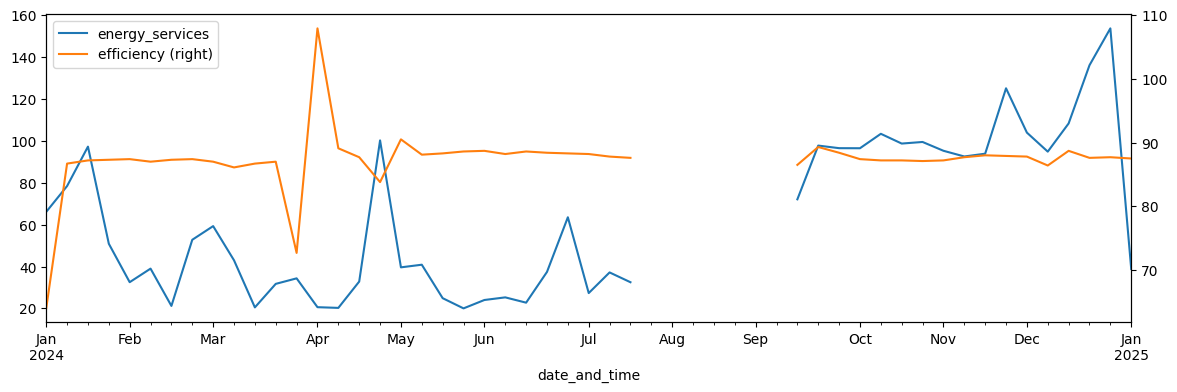

In [66]:
df_weekly[["energy_services", "efficiency"]].plot(secondary_y="efficiency")

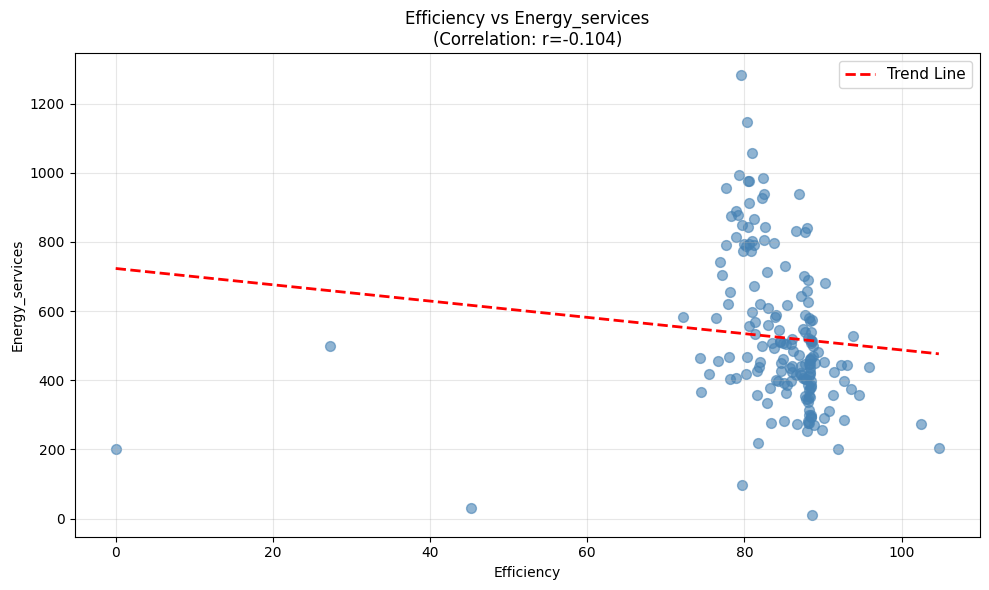

In [67]:
df_3yrs_weekly = df_3yrs[["charge_esd", "discharge_esd", "energy_services"]].resample("W-SUN").sum()
df_3yrs_weekly["efficiency"] = (df_3yrs_weekly["discharge_esd"]/df_3yrs_weekly["charge_esd"].abs())*100
df_3yrs_weekly.dropna(inplace=True)
plot_correlation(df_3yrs_weekly, "efficiency", "energy_services", df_3yrs_weekly)